In [270]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer
import stackstac
from pyproj import Transformer

print("[SYSTEM INITIALIZATION] Library stack successfully resolved.")

[SYSTEM INITIALIZATION] Library stack successfully resolved.


## Pipeline Parametrization & Target Area Mapping
Here, we configure our runtime configurations. To guarantee that our extracted array structure contains an uniform spatial pixel density ($128 \times 128$) without relying on arbitrary approximation boundaries, we dynamically query the local coordinate system UTM zone projection via the spatial center point. This gives us precise metric distance offsets.

In [271]:
# LATITUDE  = 29.741526
# LONGITUDE = 76.943030 
# karnall

# jind
# LATITUDE = 29.365606
# LONGITUDE = 76.321242

# # nashik
# LATITUDE= 19.987800
# LONGITUDE = 73.823891

# # indore
# LATITUDE = 22.801956
# LONGITUDE = 75.796062

# telangana
# LATITUDE = 18.008380
# LONGITUDE = 79.637687

#mp
LATITUDE = 22.049341
LONGITUDE = 78.953644

TARGET_PIXELS = 128
RESOLUTION_M = 10  

START_DATE = "2024-07-01"
END_DATE   = "2024-09-30"
TARGET_FRAMES = 30
CLOUD_THRESHOLD = 60.0
# CLOUD_THRESHOLD = 80.0

BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
OUTPUT_FILENAME = "file.npy"

def get_utm_bbox(lat, lon, target_pixels=128, res=10):
    zone = int((lon + 180) / 6) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    
    transformer_to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
    center_x, center_y = transformer_to_utm.transform(lon, lat)
    
    AOI_SIZE_METERS = 1280   # or 800 depending on desired zoom
    half_size = AOI_SIZE_METERS / 2
    min_x = center_x - half_size
    max_x = center_x + half_size
    min_y = center_y - half_size
    max_y = center_y + half_size
    
    transformer_to_wgs84 = Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
    west, south = transformer_to_wgs84.transform(min_x, min_y)
    east, north = transformer_to_wgs84.transform(max_x, max_y)
    
    return [min_x, min_y, max_x, max_y], [west, south, east, north], epsg

utm_bounds, wgs84_bounds, epsg_id = get_utm_bbox(LATITUDE, LONGITUDE, TARGET_PIXELS, RESOLUTION_M)
print(f"[SPATIAL RESOLUTION] Target Projected Grid EPSG: {epsg_id}")
print(f"[METRIC BOUNDS] Calculated UTM Coordinates: {utm_bounds}")

[SPATIAL RESOLUTION] Target Projected Grid EPSG: 32644
[METRIC BOUNDS] Calculated UTM Coordinates: [288174.0866119389, 2439064.5179434163, 289454.0866119389, 2440344.5179434163]


## Microsoft Planetary Computer STAC Inventory Interrogation
Using standardized, validated `pystac_client` API patterns, we query the `sentinel-2-l2a` collection. This allows us to search through thousands of records over our spatial-temporal footprint and filter out cloud-obscured scenes below our $10\%$ tolerance threshold.

In [272]:
print("[INFO] Opening link to Planetary Computer STAC endpoint...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=wgs84_bounds,
    datetime=f"{START_DATE}/{END_DATE}",
    query={"eo:cloud_cover": {"lt": CLOUD_THRESHOLD}}
)

items = search.item_collection()
print(f"[MATCHES FOUND] Total matched items available: {len(items)}\n")

print("="*60)
print("                    METADATA LOGGING EXTRACTION               ")
print("="*60)
for idx, item in enumerate(items):
    dt = item.properties.get("datetime", "N/A")[:10]
    cc = item.properties.get("eo:cloud_cover", 0.0)
    tile = item.properties.get("s2:mgrs_tile", "UNKNOWN")
    orbit = item.properties.get("sat:relative_orbit", "UNKNOWN")
    print(f"Frame {idx+1:02d} -> Date: {dt} | Cloud Cover: {cc:5.2f}% | Tile: {tile} | Orbit: {orbit}")
print("="*60)

[INFO] Opening link to Planetary Computer STAC endpoint...
[MATCHES FOUND] Total matched items available: 5

                    METADATA LOGGING EXTRACTION               
Frame 01 -> Date: 2024-09-22 | Cloud Cover: 49.65% | Tile: 44QKK | Orbit: 62
Frame 02 -> Date: 2024-09-22 | Cloud Cover: 49.53% | Tile: 43QHE | Orbit: 62
Frame 03 -> Date: 2024-08-28 | Cloud Cover: 49.03% | Tile: 44QKK | Orbit: 62
Frame 04 -> Date: 2024-08-28 | Cloud Cover: 42.23% | Tile: 43QHE | Orbit: 62
Frame 05 -> Date: 2024-07-09 | Cloud Cover: 57.36% | Tile: 43QHE | Orbit: 62


## Building the Multi-Dimensional Data Cube with `stackstac`
We transform our collection of STAC items into a uniform, continuous 4D array using `stackstac`. This leverages lazy loading to avoid pulling heavy image data into local memory until explicitly needed. It also reprojects our data directly into the target UTM projection grid.

In [273]:
stack_array = stackstac.stack(
    items,
    assets=BANDS,
    bounds=utm_bounds,
    epsg=epsg_id,
    resolution=RESOLUTION_M,
    sortby_date=True
).sel(band=BANDS)

print("[INFO] Structural representation of lazy xarray compiled:")
print(stack_array)

[INFO] Structural representation of lazy xarray compiled:
<xarray.DataArray 'stackstac-f5ef05c80d822b11641bc2e2dcfcde0e' (time: 5,
                                                                band: 6,
                                                                y: 129, x: 129)> Size: 4MB
dask.array<getitem, shape=(5, 6, 129, 129), dtype=float64, chunksize=(1, 1, 129, 129), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 40B 2024-0...
    id                                       (time) <U54 1kB 'S2A_MSIL2A_2024...
    s2:processing_baseline                   (time) <U5 100B '05.10' ... '05.11'
    s2:cloud_shadow_percentage               (time) float64 40B 8.941 ... 0.0...
    s2:thin_cirrus_percentage                (time) float64 40B 5.207 ... 10.07
    s2:dark_features_percentage              (time) object 40B 0.002551 ... None
    ...                                       ...
    s2:saturated_defective_pixel_perc

In [274]:
print(stack_array.sizes)

print(stack_array.x.min().values)
print(stack_array.x.max().values)

print(stack_array.y.min().values)
print(stack_array.y.max().values)

Frozen({'time': 5, 'band': 6, 'y': 129, 'x': 129})
288170.0
289450.0
2439070.0
2440350.0


## Data Normalization, Phenological Scaling, & Gap Filling
To make our data directly compatible with deep learning model backends, we perform three operational tasks:
2. Deduplicate overlapping same-day acquisitions using their median values.
3. Reindex the dataset to build a uniform timeline containing exactly **30 frames**, using a nearest-neighbor forward/backward filling strategy to handle data gaps seamlessly.

In [ ]:
scaled_stack = stack_array.astype(np.float32)
scaled_stack = scaled_stack.where(scaled_stack >= 0.0, np.nan)

scaled_stack['time'] = pd.to_datetime(scaled_stack.time.dt.date)

# Create the standard uniform timeline containing exactly 30 target steps
target_timeline = pd.date_range(start=START_DATE, end=END_DATE, periods=TARGET_FRAMES)

# Deduplicate same-day scenes and resample onto our 30-step target grid
daily_composites = scaled_stack.groupby("time").median(dim="time")
resampled_cube = daily_composites.reindex(time=target_timeline, method="nearest")

# Execute forward and backward fill operations to resolve residual gaps
final_filled_cube = resampled_cube.ffill(dim="time").bfill(dim="time")

# Crop the spatial dimensions to guarantee an exact 128x128 array output
dl_ready_cube = final_filled_cube.isel(x=slice(0, TARGET_PIXELS), y=slice(0, TARGET_PIXELS))

print("[PROCESSING] Executing Dask compute graph...")
numpy_tensor = dl_ready_cube.to_numpy().astype(np.float32)

print(f"\n[VERIFICATION] Final evaluation matrix shape confirmed: {numpy_tensor.shape}")
assert numpy_tensor.shape == (30, 6, 128, 128), "Critical Shape Error detected."

print(f"[SAVING] Committing output tensor cache to file path: {OUTPUT_FILENAME}")
np.save(OUTPUT_FILENAME, numpy_tensor)

[PROCESSING] Executing Dask compute graph...


## Comprehensive Tensor Data Integrity Verification
We execute a series of data integrity checks on our generated array. This verifies file structure dimensions, matches data types, and scans for data holes, infinite loops, or empty data masks before exporting to PyTorch.

In [ ]:
tensor = np.load(OUTPUT_FILENAME)
file_size_mb = os.path.getsize(OUTPUT_FILENAME) / (1024 * 1024)

print("="*60)
print("                        DATA VALIDATION REPORT                 ")
print("="*60)
print(f" * Export File Identity : {OUTPUT_FILENAME}")
print(f" * Tensor Shape Vector  : {tensor.shape} -> (Matches torch.Size)")
print(f" * Array Data Element   : {tensor.dtype}")
print(f" * File Allocation Size : {file_size_mb:.3f} Megabytes")
print(f" * Minimum Value Found  : {np.nanmin(tensor):.4f}")
print(f" * Maximum Value Found  : {np.nanmax(tensor):.4f}")
print(f" * Total NaN Elements   : {np.isnan(tensor).sum()}")
print(f" * Total Inf Elements   : {np.isinf(tensor).sum()}")
print("="*60)

                        DATA VALIDATION REPORT                 
 * Export File Identity : soft_winter_wheat.npy
 * Tensor Shape Vector  : (30, 6, 128, 128) -> (Matches torch.Size)
 * Array Data Element   : float32
 * File Allocation Size : 11.250 Megabytes
 * Minimum Value Found  : 1122.5000
 * Maximum Value Found  : 14280.0000
 * Total NaN Elements   : 0
 * Total Inf Elements   : 0


## Chronological Spatial Analysis Visualization
To visually inspect our output data cube, we isolate the True-Color channels (Red, Green, Blue) and plot five equidistant sample windows across our target timeline. We apply a robust 2-98% percentile stretch to ensure vivid, realistic visualizations.

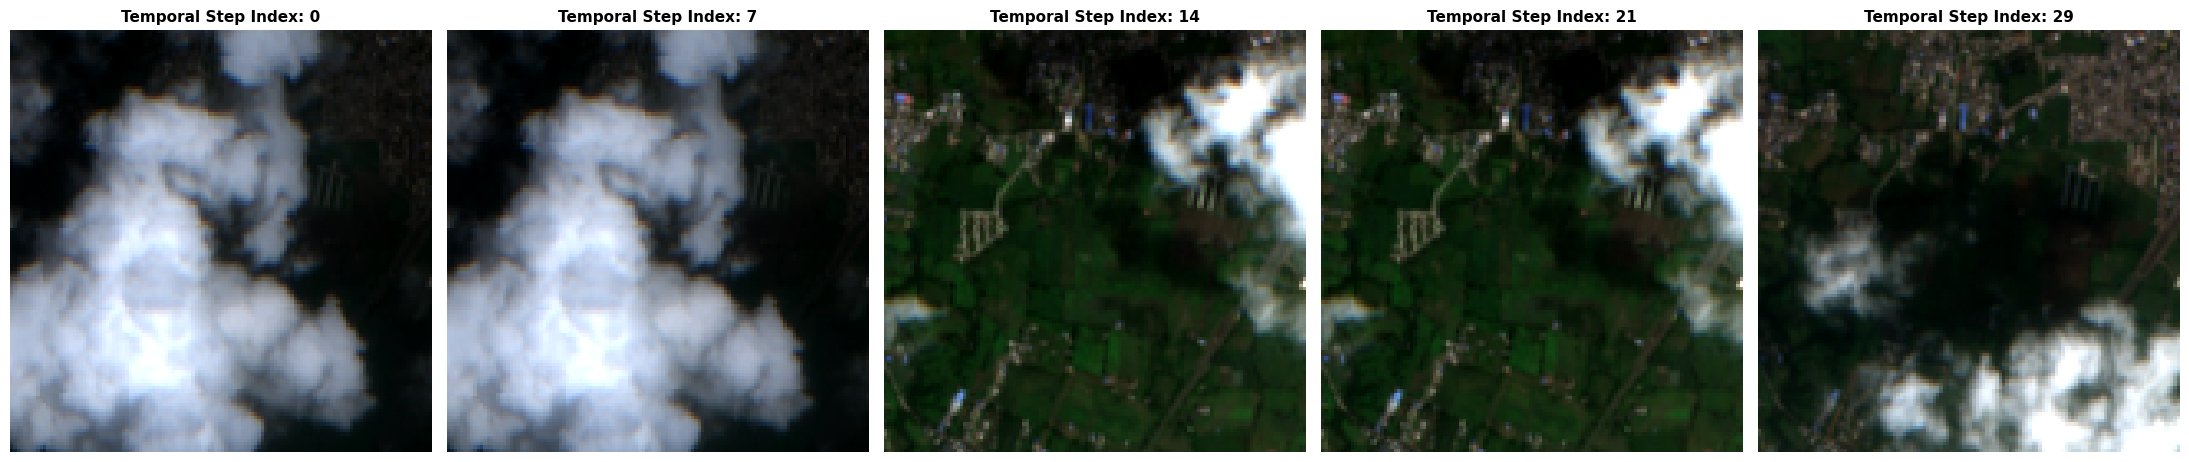

In [ ]:
# Map indices: B04 -> 2, B03 -> 1, B02 -> 0
rgb_map_indices = [2, 1, 0]
visualization_steps = np.linspace(0, TARGET_FRAMES - 1, 5, dtype=int)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, time_idx in zip(axes, visualization_steps):
    # Transpose matrix structure layout to match matplotlib: (Bands, Height, Width) -> (Height, Width, Bands)
    extracted_rgb = np.transpose(tensor[time_idx, rgb_map_indices, :, :], (1, 2, 0))
    
    # Apply percentile normalization with safety guard limits against clipping crashes
    p2, p98 = np.percentile(extracted_rgb, (2, 98))
    span_denom = (p98 - p2) if (p98 - p2) > 1e-7 else 1.0
    display_rgb = np.clip((extracted_rgb - p2) / span_denom, 0.0, 1.0)
    
    ax.imshow(display_rgb)
    ax.set_title(f"Temporal Step Index: {time_idx}", fontsize=11, fontweight="bold")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Analysis

In [ ]:
stack_array = stackstac.stack(
    items,
    assets=BANDS,
    bounds=utm_bounds,
    epsg=epsg_id,
    resolution=RESOLUTION_M,
    sortby_date=True
).sel(band=BANDS)

In [ ]:
print("="*60)
print("RAW STACK FROM PLANETARY COMPUTER")
print("="*60)

img = stack_array.compute().values

print("Shape :", img.shape)
print("Dtype :", img.dtype)
print("Min   :", np.nanmin(img))
print("Max   :", np.nanmax(img))
print("Mean  :", np.nanmean(img))
print("Std   :", np.nanstd(img))

band_names = ["B02","B03","B04","B08","B11","B12"]

for i, name in enumerate(band_names):
    print(
        f"{name}: "
        f"min={np.nanmin(img[:,i]):.2f}, "
        f"max={np.nanmax(img[:,i]):.2f}, "
        f"mean={np.nanmean(img[:,i]):.2f}, "
        f"std={np.nanstd(img[:,i]):.2f}"
    )

RAW STACK FROM PLANETARY COMPUTER
Shape : (5, 6, 129, 129)
Dtype : float64
Min   : 1113.0
Max   : 14280.0
Mean  : 3176.9196943292673
Std   : 1927.5058917340414
B02: min=1113.00, max=14280.00, mean=2890.54, std=2439.35
B03: min=1145.00, max=13128.00, mean=2947.49, std=2142.72
B04: min=1121.00, max=12576.00, mean=2754.10, std=2068.67
B08: min=1503.00, max=11392.00, mean=4183.44, std=1578.45
B11: min=1479.00, max=8627.00, mean=3479.16, std=1351.03
B12: min=1248.00, max=9911.00, mean=2806.79, std=1264.51
